# 04 — Model Selection & Hyperparameter Tuning

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Cross-validated search over every models
- Pick the best model by CV ROC-AUC
- Final evaluation on the untouched test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load data (scaled splits from Notebook 02)
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")

X_tr = np.vstack([X_train, X_valid])
y_tr = np.concatenate([y_train, y_valid])

# Use 10-fold CV for more robust evaluation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_configs = []

# Logistic Regression - expanded search space
grid_configs.append((
    "LogisticRegression",
    LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42),
    {"C":[0.01, 0.1, 1.0, 10.0], "penalty":["l2"]}
))

# Random Forest - more comprehensive grid
grid_configs.append((
    "RandomForest",
    RandomForestClassifier(random_state=42),
    {"n_estimators":[200, 400, 800], 
     "max_depth":[None, 5, 10, 15, 20, 25],
     "min_samples_leaf":[1, 2, 3],
     "min_samples_split":[3, 4, 5, 6, 7]}
))

# SVM - expanded parameter grid
grid_configs.append((
    "SVM",
    SVC(probability=True, random_state=42),
    {"C":[0.1, 1, 10], 
     "kernel":["rbf", "linear"], 
     "gamma":["scale", "auto", 0.001, 0.01]}
))

# KNN - expanded search
grid_configs.append((
    "KNeighbors",
    KNeighborsClassifier(),
    {"n_neighbors":list(range(3, 21, 2)), 
     "weights":["uniform", "distance"],
     "metric":["manhattan", "euclidean"]}
))

# Decision Tree - more comprehensive
grid_configs.append((
    "DecisionTree",
    DecisionTreeClassifier(criterion="gini", random_state=42),
    {"max_depth":[5, 10, 15, 20, 25],
     "min_samples_leaf":[1, 2, 3],
     "min_samples_split":[3, 4, 5, 6, 7]}
))

# Gaussian Naive Bayes
grid_configs.append((
    "GaussianNB",
    GaussianNB(),
    {"var_smoothing":[1e-9, 1e-8, 1e-7, 1e-6]}
))

# Gradient Boosting - 
grid_configs.append((
    "GradientBoosting",
    GradientBoostingClassifier(random_state=42),
    {"n_estimators":[100, 200, 400],
     "learning_rate":[0.01, 0.05, 0.1, 0.15],
     "max_depth":[2, 3, 4]}
))

cv_results = []
best_models = {}

for name, est, params in grid_configs:
    print(f"\n{'='*60}")
    print(f"Training {name} with 10-fold CV...")
    print(f"{'='*60}")
    
    grid = GridSearchCV(
        estimator=est, param_grid=params, scoring="roc_auc",
        cv=cv, n_jobs=-1, verbose=1, refit=True
    )
    grid.fit(X_tr, y_tr)
    best_models[name] = grid.best_estimator_
    
    # Calculate all metrics on validation set
    y_pred_val = grid.best_estimator_.predict(X_valid)
    y_prob_val = grid.best_estimator_.predict_proba(X_valid)[:, 1] if hasattr(grid.best_estimator_, 'predict_proba') else None
    
    print(f"Best params: {grid.best_params_}")
    print(f"CV ROC-AUC: {grid.best_score_:.4f}")
    
    cv_results.append({
        "model": name,
        "best_params": grid.best_params_,
        "cv_roc_auc": grid.best_score_,
        "val_accuracy": accuracy_score(y_valid, y_pred_val),
        "val_precision": precision_score(y_valid, y_pred_val),
        "val_recall": recall_score(y_valid, y_pred_val),
        "val_f1": f1_score(y_valid, y_pred_val),
        "val_roc_auc": roc_auc_score(y_valid, y_prob_val) if y_prob_val is not None else None
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_roc_auc", ascending=False)
cv_df


Training LogisticRegression with 10-fold CV...
Fitting 10 folds for each of 4 candidates, totalling 40 fits
Best params: {'C': 1.0, 'penalty': 'l2'}
CV ROC-AUC: 0.8268

Training RandomForest with 10-fold CV...
Fitting 10 folds for each of 270 candidates, totalling 2700 fits
Best params: {'C': 1.0, 'penalty': 'l2'}
CV ROC-AUC: 0.8268

Training RandomForest with 10-fold CV...
Fitting 10 folds for each of 270 candidates, totalling 2700 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 800}
CV ROC-AUC: 0.8448

Training SVM with 10-fold CV...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 800}
CV ROC-AUC: 0.8448

Training SVM with 10-fold CV...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
CV ROC-AUC: 0.8368

Training KNeighbors with 10-fold CV...
Fittin

,model,best_params,cv_roc_auc,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
6,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.862206,1.000000,1.000000,1.000000,1.000000,1.000000
1,RandomForest,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.844780,1.000000,1.000000,1.000000,1.000000,1.000000
2,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.836813,0.833333,0.863636,0.791667,0.826087,0.930556
0,LogisticRegression,"{'C': 1.0, 'penalty': 'l2'}",0.826845,0.875000,0.846154,0.916667,0.880000,0.920139
3,KNeighbors,"{'metric': 'manhattan', 'n_neighbors': 19, 'we...",0.739050,1.000000,1.000000,1.000000,1.000000,1.000000
4,DecisionTree,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.720565,0.854167,0.947368,0.750000,0.837209,0.925347
5,GaussianNB,{'var_smoothing': 1e-08},0.679474,0.604167,1.000000,0.208333,0.344828,0.746528


## Evaluate top all model on the *test* set

In [2]:
# Evaluate ALL models on the test set
print("="*70)
print("EVALUATING ALL MODELS ON TEST SET")
print("="*70)

test_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    test_metrics = {
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }
    test_results.append(test_metrics)

test_df = pd.DataFrame(test_results).sort_values("test_roc_auc", ascending=False)
test_df

EVALUATING ALL MODELS ON TEST SET


,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
2,SVM,0.854167,0.904762,0.791667,0.844444,0.916667
1,RandomForest,0.812500,0.800000,0.833333,0.816327,0.907986
0,LogisticRegression,0.875000,0.875000,0.875000,0.875000,0.901042
6,GradientBoosting,0.729167,0.703704,0.791667,0.745098,0.880208
3,KNeighbors,0.729167,0.823529,0.583333,0.682927,0.842014
5,GaussianNB,0.520833,1.000000,0.041667,0.080000,0.727431
4,DecisionTree,0.708333,0.750000,0.625000,0.681818,0.701389


## Detailed Analysis of Top Model

Top model on test set: SVM
Best params: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Classification Report (Test):

              precision    recall  f1-score   support

No Gallstone       0.81      0.92      0.86        24
   Gallstone       0.90      0.79      0.84        24

    accuracy                           0.85        48
   macro avg       0.86      0.85      0.85        48
weighted avg       0.86      0.85      0.85        48



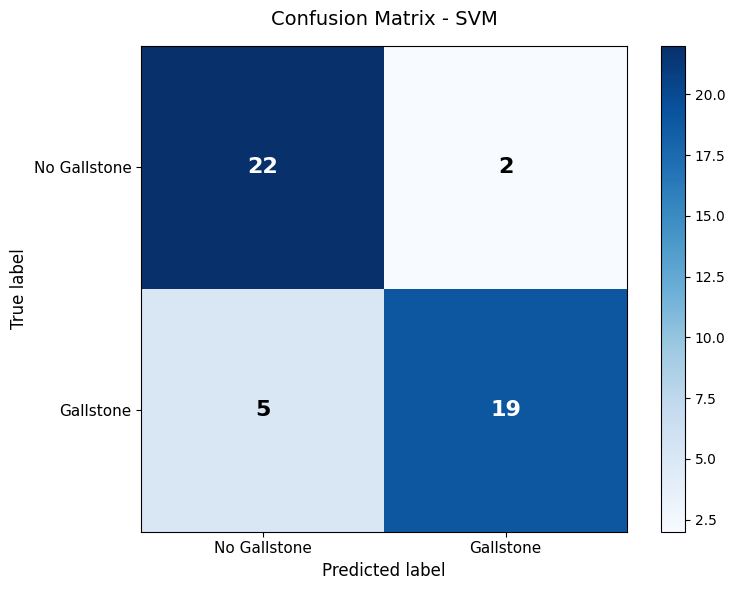

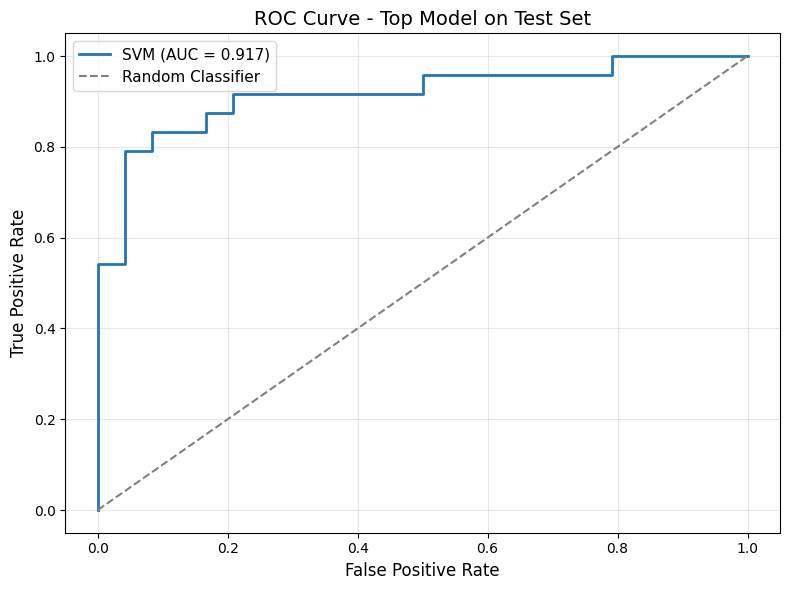


Test ROC-AUC: 0.9167


In [3]:
top_name = test_df.iloc[0]["model"]
top_model = best_models[top_name]
print("Top model on test set:", top_name)
print("Best params:", top_model.get_params())

y_pred = top_model.predict(X_test)
y_prob = top_model.predict_proba(X_test)[:,1]

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_pred, target_names=["No Gallstone", "Gallstone"]))

cm = confusion_matrix(y_test, y_pred)

# Create figure with proper labels
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)

# Set ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Gallstone", "Gallstone"], fontsize=11)
ax.set_yticklabels(["No Gallstone", "Gallstone"], fontsize=11)

# Add labels
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title(f"Confusion Matrix - {top_name}", fontsize=14, pad=15)

# Add values in cells
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, str(cm[i, j]),
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=16, weight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{top_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Top Model on Test Set", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC: {test_auc:.4f}")

In [4]:
# Save the best model and results for use in interpretation notebook
import joblib

# Merge CV and test results and sort by test performance
final_results = cv_df.merge(test_df, on="model", how="left")
final_results = final_results.sort_values("test_roc_auc", ascending=False)

# Save best model (top performer on test set)
top_test_model = best_models[test_df.iloc[0]["model"]]
joblib.dump(top_test_model, "../data/models/final_model.joblib")

# Save comprehensive model comparison results (sorted by test performance)
final_results.to_csv("../data/models/model_selection_results.csv", index=False)

print(f"✅ Saved best model ({test_df.iloc[0]['model']}) to: ../data/models/final_model.joblib")
print(f"✅ Saved comprehensive results to: ../data/models/model_selection_results.csv")

# Display final comparison
print(f"\n📋 Model Comparison Summary:")
print("="*70)
final_results[['model', 'cv_roc_auc', 'test_roc_auc', 'test_accuracy', 'test_f1']].round(4)

✅ Saved best model (SVM) to: ../data/models/final_model.joblib
✅ Saved comprehensive results to: ../data/models/model_selection_results.csv

📋 Model Comparison Summary:


,model,cv_roc_auc,test_roc_auc,test_accuracy,test_f1
2,SVM,0.8368,0.9167,0.8542,0.8444
1,RandomForest,0.8448,0.9080,0.8125,0.8163
3,LogisticRegression,0.8268,0.9010,0.8750,0.8750
0,GradientBoosting,0.8622,0.8802,0.7292,0.7451
4,KNeighbors,0.7391,0.8420,0.7292,0.6829
6,GaussianNB,0.6795,0.7274,0.5208,0.0800
5,DecisionTree,0.7206,0.7014,0.7083,0.6818
